# 融合权重搜索

`05_submission_boosting_blend.csv` 的公榜分数为 `0.12585`，说明 Lasso 与 XGBoost 的融合方向有效。本 notebook 不新增复杂特征，只搜索 Lasso、ElasticNet、XGBoost 的融合权重，目标是在保留稳定性的前提下继续小幅提升。

## 1. 导入依赖与读取数据

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNetCV, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "data"
SUBMISSION_DIR = ROOT / "submissions"

train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

train.shape, test.shape

((1460, 81), (1459, 80))

## 2. 复用当前最佳数据处理

继续使用已经被 Kaggle 公榜验证有效的处理：移除明显异常点，并对偏态数值特征做 `log1p`。

In [2]:
target = "SalePrice"
id_column = "Id"

outlier_mask = (train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)
train_model = train.loc[~outlier_mask].copy()

X = train_model.drop(columns=[target, id_column])
y = train_model[target]
X_test = test.drop(columns=[id_column]).copy()
test_ids = test[id_column]

print("移除异常点数量:", int(outlier_mask.sum()))
print("异常点 Id:", train.loc[outlier_mask, id_column].tolist())

移除异常点数量: 2
异常点 Id: [524, 1299]


In [3]:
def log_transform_skewed_features(X_train: pd.DataFrame, X_test: pd.DataFrame, threshold: float = 0.75):
    X_train = X_train.copy()
    X_test = X_test.copy()
    numeric_columns = X_train.select_dtypes(include="number").columns
    skewness = X_train[numeric_columns].skew().sort_values(ascending=False)
    skewed_columns = skewness[skewness > threshold].index.tolist()

    transformed_columns = []
    for column in skewed_columns:
        min_value = min(X_train[column].min(), X_test[column].min())
        if pd.notna(min_value) and min_value >= 0:
            X_train[column] = np.log1p(X_train[column])
            X_test[column] = np.log1p(X_test[column])
            transformed_columns.append(column)

    return X_train, X_test, transformed_columns


X_log, X_test_log, transformed_columns = log_transform_skewed_features(X, X_test)
print("log1p 处理的列数量:", len(transformed_columns))

log1p 处理的列数量: 20


## 3. 建模函数

In [4]:
def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_model(base_model, scale_numeric: bool = False) -> TransformedTargetRegressor:
    numeric_features = X_log.select_dtypes(include="number").columns.tolist()
    categorical_features = X_log.select_dtypes(exclude="number").columns.tolist()

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline(numeric_steps), numeric_features),
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", make_one_hot_encoder()),
                    ]
                ),
                categorical_features,
            ),
        ]
    )

    return TransformedTargetRegressor(
        regressor=Pipeline(steps=[("preprocessor", preprocessor), ("model", base_model)]),
        func=np.log1p,
        inverse_func=np.expm1,
    )


def rmsle(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_pred = np.maximum(y_pred, 0)
    return float(np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred))))

## 4. 训练 OOF 预测

先为每个模型生成 out-of-fold 预测，再用这些 OOF 预测搜索融合权重。这样比直接看训练集预测更稳。

In [5]:
models = {
    "lasso": build_model(
        LassoCV(alphas=np.logspace(-4, 0, 40), cv=5, max_iter=30000, random_state=42),
        scale_numeric=True,
    ),
    "elasticnet": build_model(
        ElasticNetCV(
            l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
            alphas=np.logspace(-4, 0, 40),
            cv=5,
            max_iter=30000,
            random_state=42,
        ),
        scale_numeric=True,
    ),
    "xgboost": build_model(
        XGBRegressor(
            n_estimators=900,
            learning_rate=0.03,
            max_depth=3,
            subsample=0.85,
            colsample_bytree=0.75,
            reg_lambda=1.5,
            reg_alpha=0.001,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1,
        )
    ),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
oof_predictions = {name: np.zeros(len(X_log)) for name in models}

for train_idx, valid_idx in cv.split(X_log):
    for name, model in models.items():
        fold_model = clone(model)
        fold_model.fit(X_log.iloc[train_idx], y.iloc[train_idx])
        oof_predictions[name][valid_idx] = fold_model.predict(X_log.iloc[valid_idx])

single_scores = pd.DataFrame(
    [{"方案": name, "OOF_RMSLE": rmsle(y, preds)} for name, preds in oof_predictions.items()]
).sort_values("OOF_RMSLE")

single_scores

,方案,OOF_RMSLE
0,lasso,0.110142
1,elasticnet,0.110269
2,xgboost,0.115779


## 5. 粗搜索融合权重

In [6]:
rows = []

for w_lasso in np.arange(0.55, 0.91, 0.05):
    w_xgb = 1 - w_lasso
    prediction = w_lasso * oof_predictions["lasso"] + w_xgb * oof_predictions["xgboost"]
    rows.append(
        {
            "方案": "lasso_xgboost",
            "w_lasso": round(w_lasso, 2),
            "w_elasticnet": 0.0,
            "w_xgboost": round(w_xgb, 2),
            "OOF_RMSLE": rmsle(y, prediction),
        }
    )

for w_lasso in np.arange(0.50, 0.86, 0.05):
    for w_elasticnet in np.arange(0.05, 0.31, 0.05):
        w_xgb = 1 - w_lasso - w_elasticnet
        if w_xgb < 0.05:
            continue
        prediction = (
            w_lasso * oof_predictions["lasso"]
            + w_elasticnet * oof_predictions["elasticnet"]
            + w_xgb * oof_predictions["xgboost"]
        )
        rows.append(
            {
                "方案": "lasso_elasticnet_xgboost",
                "w_lasso": round(w_lasso, 2),
                "w_elasticnet": round(w_elasticnet, 2),
                "w_xgboost": round(w_xgb, 2),
                "OOF_RMSLE": rmsle(y, prediction),
            }
        )

coarse_results = pd.DataFrame(rows).sort_values("OOF_RMSLE")
coarse_results.head(15)

,方案,w_lasso,w_elasticnet,w_xgboost,OOF_RMSLE
2,lasso_xgboost,0.65,0.00,0.35,0.107800
20,lasso_elasticnet_xgboost,0.60,0.05,0.35,0.107805
15,lasso_elasticnet_xgboost,0.55,0.10,0.35,0.107811
10,lasso_elasticnet_xgboost,0.50,0.15,0.35,0.107817
3,lasso_xgboost,0.70,0.00,0.30,0.107846
1,lasso_xgboost,0.60,0.00,0.40,0.107850
26,lasso_elasticnet_xgboost,0.65,0.05,0.30,0.107852
14,lasso_elasticnet_xgboost,0.55,0.05,0.40,0.107856
21,lasso_elasticnet_xgboost,0.60,0.10,0.30,0.107858
9,lasso_elasticnet_xgboost,0.50,0.10,0.40,0.107861


## 6. 细搜索 Lasso / XGBoost 权重

粗搜索显示 ElasticNet 几乎没有带来额外收益，所以在 Lasso 与 XGBoost 之间做更细的权重搜索。

In [7]:
fine_rows = []
for w_lasso in np.arange(0.60, 0.701, 0.01):
    w_xgb = 1 - w_lasso
    prediction = w_lasso * oof_predictions["lasso"] + w_xgb * oof_predictions["xgboost"]
    fine_rows.append(
        {
            "w_lasso": round(w_lasso, 2),
            "w_xgboost": round(w_xgb, 2),
            "OOF_RMSLE": rmsle(y, prediction),
        }
    )

fine_results = pd.DataFrame(fine_rows).sort_values("OOF_RMSLE")
fine_results

,w_lasso,w_xgboost,OOF_RMSLE
5,0.65,0.35,0.107800
6,0.66,0.34,0.107801
4,0.64,0.36,0.107802
7,0.67,0.33,0.107807
3,0.63,0.37,0.107808
8,0.68,0.32,0.107816
2,0.62,0.38,0.107818
9,0.69,0.31,0.107829
1,0.61,0.39,0.107832
10,0.70,0.30,0.107846


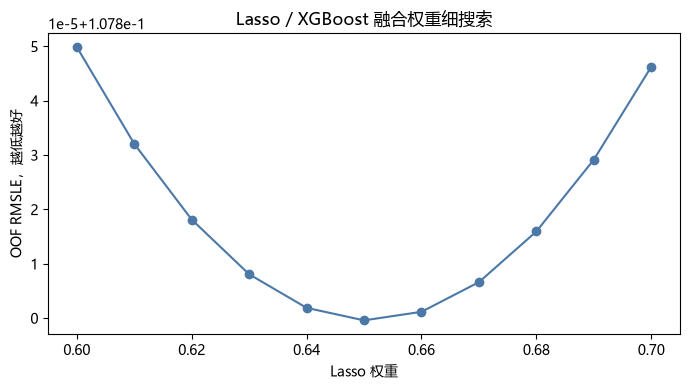

In [8]:
ax = fine_results.sort_values("w_lasso").plot(
    x="w_lasso",
    y="OOF_RMSLE",
    marker="o",
    legend=False,
    figsize=(7, 4),
    color="#4C78A8",
)
ax.set_title("Lasso / XGBoost 融合权重细搜索")
ax.set_xlabel("Lasso 权重")
ax.set_ylabel("OOF RMSLE，越低越好")
plt.tight_layout()

## 7. 生成加权融合提交文件

In [9]:
best_weight = fine_results.iloc[0]
w_lasso = float(best_weight["w_lasso"])
w_xgboost = float(best_weight["w_xgboost"])

lasso_model = clone(models["lasso"])
xgboost_model = clone(models["xgboost"])
lasso_model.fit(X_log, y)
xgboost_model.fit(X_log, y)

lasso_prediction = lasso_model.predict(X_test_log)
xgboost_prediction = xgboost_model.predict(X_test_log)
final_prediction = np.maximum(w_lasso * lasso_prediction + w_xgboost * xgboost_prediction, 0)

submission = pd.DataFrame({"Id": test_ids, "SalePrice": final_prediction})
SUBMISSION_DIR.mkdir(exist_ok=True)
submission_path = SUBMISSION_DIR / "06_submission_weighted_blend.csv"
submission.to_csv(submission_path, index=False)

w_lasso, w_xgboost, submission_path, submission.head(), submission["SalePrice"].describe()

(0.65,
 0.35,
 WindowsPath('C:/Users/84740/house-prices-advanced-regression/submissions/06_submission_weighted_blend.csv'),
      Id      SalePrice
 0  1461  120500.729881
 1  1462  154619.764962
 2  1463  183403.994934
 3  1464  197433.733614
 4  1465  191987.176148,
 count      1459.000000
 mean     178711.989023
 std       78883.370538
 min       41959.897754
 25%      126306.597733
 50%      157276.196784
 75%      210660.649140
 max      882093.667476
 Name: SalePrice, dtype: float64)

## 8. 提交命令

```powershell
kaggle competitions submit -c house-prices-advanced-regression-techniques -f submissions/06_submission_weighted_blend.csv -m "weighted lasso xgboost blend"
```